# PRÁCTICA 2: ISOMAP - UMAP - TSNE
## | FCEIA - Tec. Universitaria en Inteligencia Artificial - Minería de Datos


# Sobre el dataset

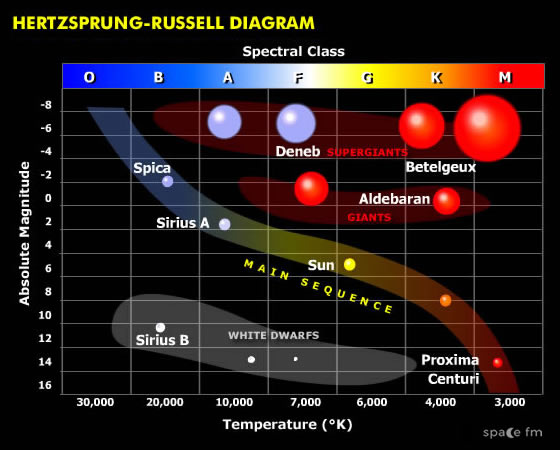

El dataset contiene 7 columnas:
- Temperature (K): temperatura de la superficie de una estrella.
- Luminosity (L/Lo): Luminosidad de una estrella calculada con respecto al Sol.
- Radius(R/Ro): Radio de una estrella calculado respecto al Sol.
- Absolute Magnitude: Magnitud absoluta visual de una estrella.
- Star Type: Tipo de estrella **variable objetivo**.
- Star color: color de la estrella tras un análisis espectral hecho.
- Spectral class: clase espectral de cada estrella.


https://www.kaggle.com/datasets/deepu1109/star-dataset

# Librerías

In [132]:
# !pip install gdown

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS, Isomap, TSNE
import os

In [134]:
import gdown

# ID del archivo
file_id = "1MNmPEquEAy6mzipINRr1NUg07RrlwiNR"
# URL directa para gdown
url = f"https://drive.google.com/uc?id={file_id}"

# Descargar
output = "star-dataset.csv"  # Cambia el nombre según corresponda
gdown.download(url, output, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1MNmPEquEAy6mzipINRr1NUg07RrlwiNR
To: /content/star-dataset.csv
100%|██████████| 8.48k/8.48k [00:00<00:00, 19.2MB/s]


'star-dataset.csv'

# Carga de datos

In [135]:
df = pd.read_csv('star-dataset.csv')

In [136]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [137]:
df['Star type'] = df['Star type'].astype('category')
star_type_map = {
    0: 'Brown Dwarf',
    1: 'Red Dwarf',
    2:'White Dwarf',
    3:'Main Sequence',
    4:'Supergiant',
    5: 'Hypergiant'
}
df['Star type'] = df['Star type'].map(star_type_map)

# Análisis exploratorio

## Hisograma

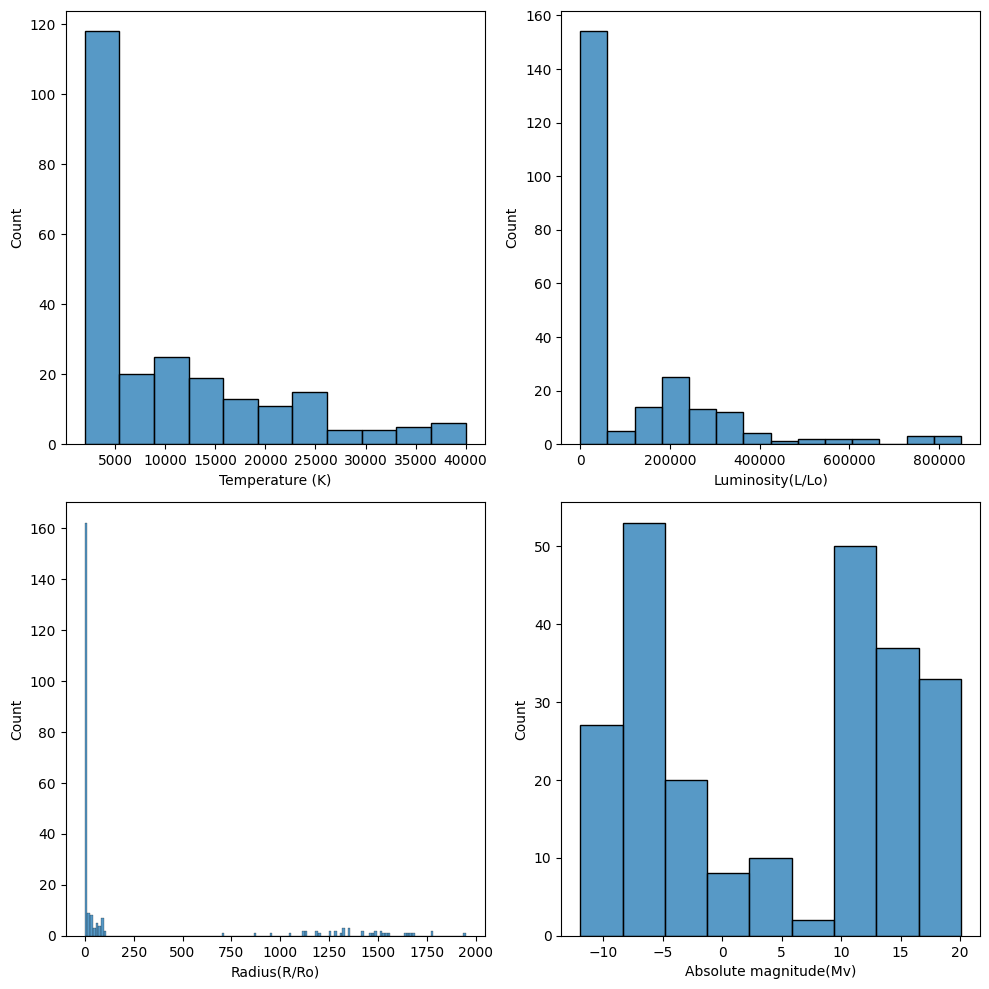

In [138]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))

sns.histplot(data=df, x='Temperature (K)', ax=axs[0,0])
sns.histplot(data=df, x='Luminosity(L/Lo)', ax=axs[0,1])
sns.histplot(data=df, x='Radius(R/Ro)', ax=axs[1,0])
sns.histplot(data=df, x='Absolute magnitude(Mv)', ax=axs[1,1])

plt.tight_layout()
plt.show()

## Boxplot

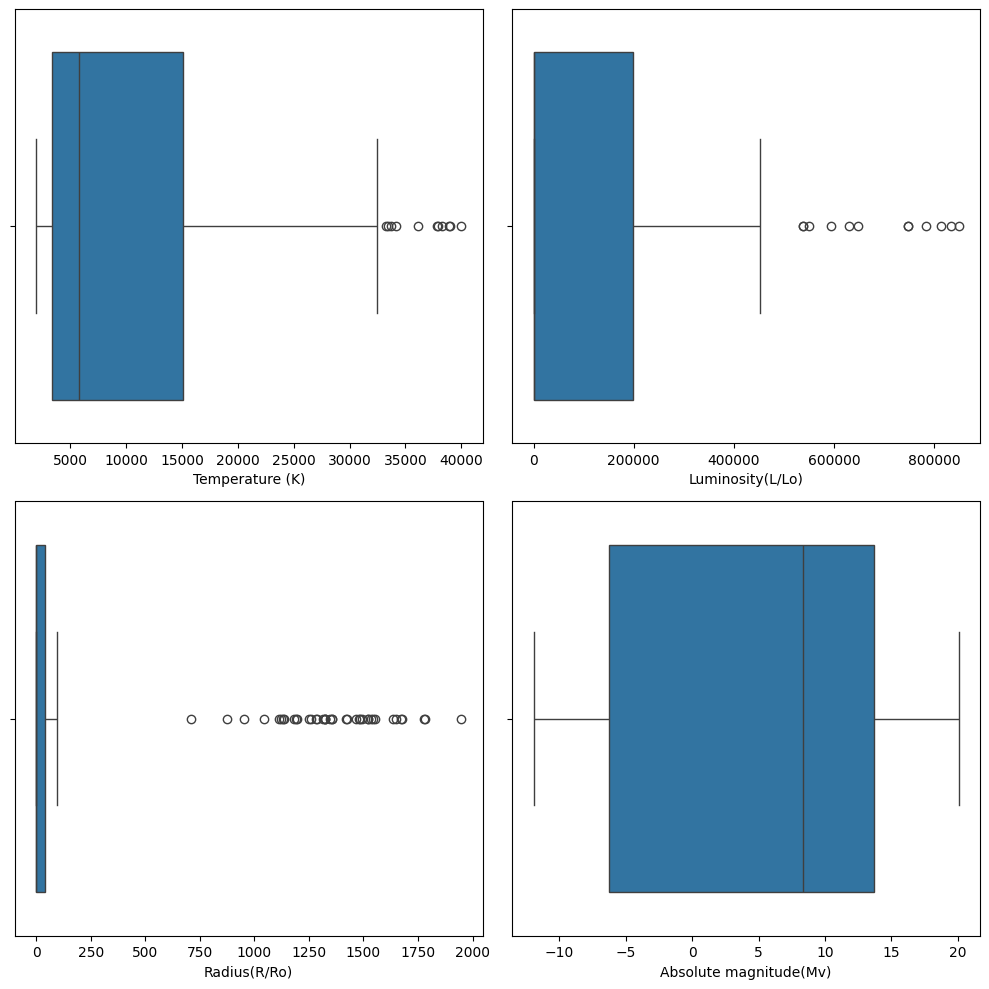

In [139]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))

sns.boxplot(data=df, x='Temperature (K)', ax=axs[0,0])
sns.boxplot(data=df, x='Luminosity(L/Lo)', ax=axs[0,1])
sns.boxplot(data=df, x='Radius(R/Ro)', ax=axs[1,0])
sns.boxplot(data=df, x='Absolute magnitude(Mv)', ax=axs[1,1])

plt.tight_layout()
plt.show()

## Pairplot

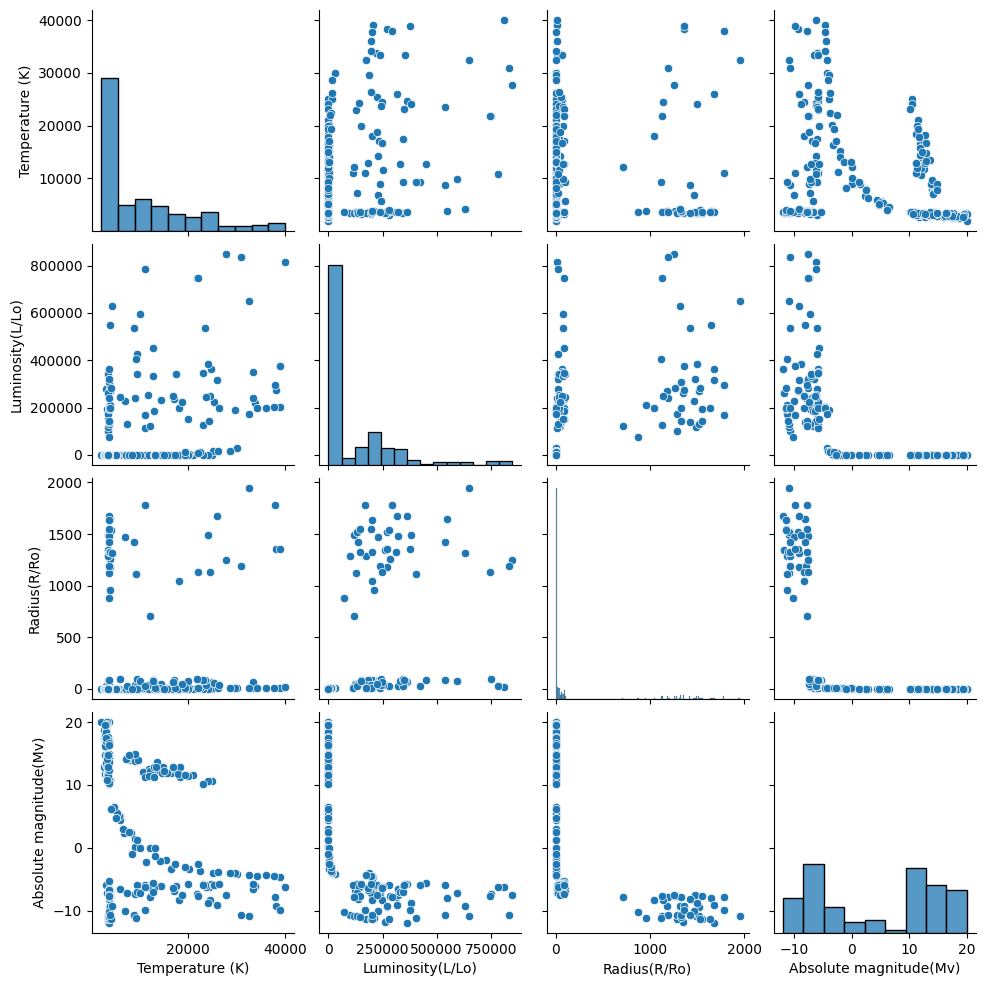

In [140]:
sns.pairplot(df.drop(['Star type'], axis = 1))

## Correlación Lineal

<Axes: >

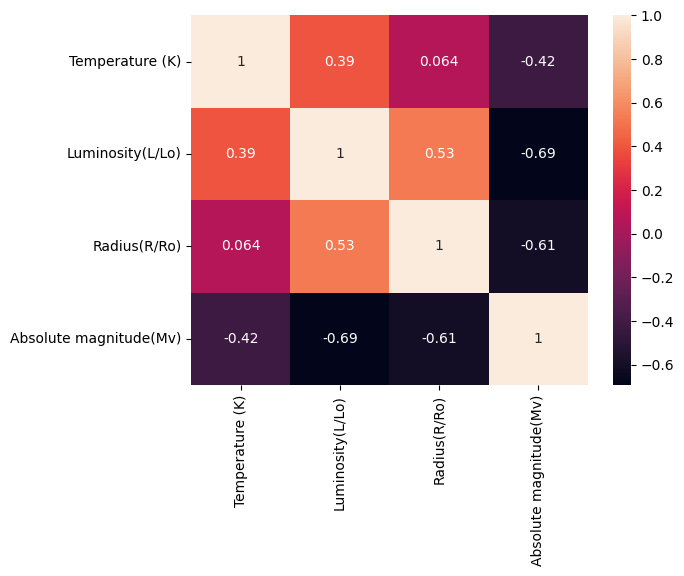

In [141]:
df_corr = df[['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']]
sns.heatmap(df_corr.corr(), annot=True)

# 🔴 CONSIGNA - Sección Análisis Descriptivo
| Haz un análisis sobre los atípicos y luego responde qué decisión tomarías.

| Pista: diferenciar por tipo de estrella para ver el comportamiento de cada variable.

| Responde:

- ¿Qué decisión tomarías con respecto a estos outliers? (eliminarlos, transformarlos, conservarlos, etc.)

- ¿Qué otras relaciones entre variables podrías analizar para fundamentar mejor tu decisión?

# División X, y

Quitamos las columnas categóricas ya que no las utilizaremos en los métodos a ver.

In [142]:
categorical_columns = ['Star type', 'Star color', 'Spectral Class']

Separamos la columna que contiene el tipo de estrella de los otros atributos.

In [143]:
X = df.drop(columns=['Star type'])
X = df.drop(columns=categorical_columns)
y = df['Star type']

# Escalado

Escalamos los datos ya que algunos métodos de reducción de dimensionalidad dependen de las distancias entre puntos, y si las variables están en diferentes escalas, una podría dominar sobre las demás.

Al escalar, todas las variables aportan de manera equitativa al cálculo de similitudes y proyecciones.

In [144]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std.shape

(240, 4)

# Isomap

ISOMAP es un método de reducción de dimensionalidad no lineal que preserva las distancias geodésicas (caminos más cortos en el grafo de vecinos) para representar los datos en un espacio de menor dimensión, manteniendo su estructura global.

## Armado de Isomap

In [145]:
isomap = Isomap(n_neighbors=6, n_components=4)
X_reduced = isomap.fit_transform(X_std)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning:

The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are m

In [146]:
X_reduced.shape

(240, 4)

In [147]:
df_isomap = pd.DataFrame(X_reduced, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_isomap['Star type'] = y

## Correlaciones

Corroboramos que la correlación sea baja

<Axes: >

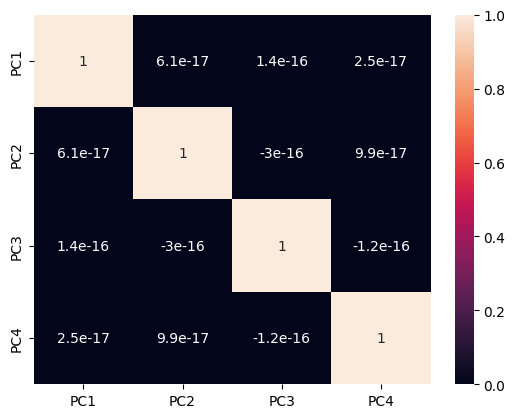

In [148]:
corr_isomap = df_isomap.drop(columns='Star type').corr()
sns.heatmap(corr_isomap, annot=True)

## Ploteo ISOMAP

In [149]:
# Mostrar ISOMAP con y discreto
fig_isomap_2d = px.scatter(df_isomap, x='PC1', y='PC2', color = y,
                    labels = {'color':'Star type', 0:'PC1',1:'PC2'},
                    title='ISOMAP')
fig_isomap_2d.show()

In [150]:
# Mostrar ISOMAP 3D con y
fig_isomap_3d = px.scatter_3d(df_isomap, x='PC1', y='PC2', z='PC3', color = y,
                    labels = {'color':'Star type', 0:'PC1',1:'PC2',2:'PC3'},
                    title='ISOMAP')
fig_isomap_3d.show()

# 🔴 CONSIGNA - Sección ISOMAP
| Aplica ISOMAP variando los parámetros de la siguiente forma:

- n_neighbors muy alto y n_components muy bajo.

- n_neighbors muy bajo y n_components muy alto.

- n_neighbors muy alto y n_components muy alto.

- n_neighbors muy bajo y n_components muy bajo.

| Realiza un gráfico para cada caso y luego responde:

- ¿Qué cambios observas en la representación?

- ¿Cómo influye n_neighbors en la preservación de la estructura local o global?

- ¿Cómo influye n_components en la calidad de la proyección?

- ¿Cuál de las combinaciones consideras más apropiada para tu dataset y por qué?

# T-SNE

## Armado T-SNE

In [151]:
tsne = TSNE(n_components=3, init='random', method='exact', random_state=42)
X_reduced_tsne = tsne.fit_transform(X_std)
print(X_reduced_tsne.shape)

tsne_df = pd.DataFrame(
    data=X_reduced_tsne,
    columns=['CP1', 'CP2', 'CP3'])
tsne_df['category'] = y

(240, 3)


## Correlación

<Axes: >

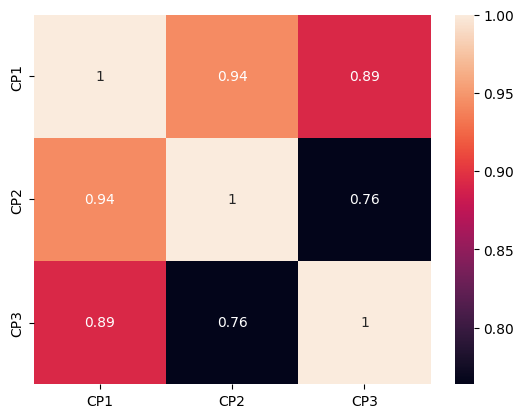

In [152]:
# Correlación
corr_tsne = tsne_df.drop(columns='category').corr()
sns.heatmap(corr_tsne, annot=True)

In [153]:
# Mostrar TSNE con y discreto
fig_tsne_2d = px.scatter(tsne_df, x='CP1', y='CP2', color = y,
                    labels = {'color':'Star type', 0:'PC1',1:'PC2'},
                    title='TSNE 2D Con CP1 y CP2')
fig_tsne_2d.show()

In [154]:
# Mostrar TSNE 3D con y discreto
fig_tsne_3d = px.scatter_3d(tsne_df, x='CP1', y='CP2', z = 'CP3', color = y,
                    labels = {'color':'Star type', 0:'CP1',1:'CP2', 2: 'CP3'},
                    title='TSNE 3D Con CP1, CP2 Y CP3')
fig_tsne_3d.show()

# 🔴 CONSIGNA - Sección T-SNE

| Vuelve a aplicar t-SNE pero elimina la columna 'Temperature (K)' del dataset.

| Compara el resultado con la versión original e interpreta:

- ¿Qué cambios observas en la separación de clústeres?

- ¿A qué se deben estos cambios? Relaciónalos con lo que encontraste en el Análisis Exploratorio (EDA).

| Prueba también variar los parámetros de t-SNE (por ejemplo, perplexity o learning_rate) y analiza cómo afectan la representación.

# U - Map

In [155]:
# ! pip install umap-learn

In [156]:
import umap

In [157]:
umap_2d = umap.UMAP(n_components=2, init='random', random_state=0)

In [158]:
proj_2d = umap_2d.fit_transform(X_std)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [159]:
# Mostrar UMAP con y discreto
fig_umap_2d = px.scatter(proj_2d, x=0, y=1, color = y,
                    labels = {'color':'Star type', 0:'CP1',1:'CP2'},
                    title='UMAP con CP1 y CP2')
fig_umap_2d.show()

In [160]:
umap_3d = umap.UMAP(n_components=3, init='random', random_state=1)

In [161]:
proj_3d = umap_3d.fit_transform(X_std)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [162]:
# Mostrar UMAP con y discreto
fig_umap_3d = px.scatter_3d(proj_3d, x=0, y=1, z = 2, color = y,
                    labels = {'color':'Star type', 0:'CP1',1:'CP2', 2: 'CP3'},
                    title='UMAP 3D con CP1, CP2 y CP3')
fig_umap_3d.show()

# 🔴 CONSIGNA — Sección UMAP

| Prueba UMAP variando los parámetros principales:

- n_neighbors (ej. muy bajo vs. muy alto)

| Haz un plot de cada caso y compara:

- ¿Cómo cambian la compactación y separación de los clústeres?

- ¿Qué valor te parece más adecuada para tu dataset?

- ¿Qué relación encuentras con el análisis exploratorio (EDA) respecto a las variables y a la presencia de atípicos?

| Bonus: compara los resultados de UMAP con los de t-SNE e ISOMAP.

- ¿Qué ventajas o desventajas encontrás en cada método?

# Comparación

In [163]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('ISOMAP 2D', 't-SNE 2D', 'UMAP 2D'))

for trace in fig_isomap_2d.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_tsne_2d.data:
    fig.add_trace(trace, row=1, col=2)

for trace in fig_umap_2d.data:
    fig.add_trace(trace, row=1, col=3)


fig.update_layout(height=400, showlegend=True)

fig.show()